<a href="https://colab.research.google.com/github/hikaaru13/PCVK-GANJIL-TUGAS/blob/main/PERTANYAAN_PRAKTIKUM_PERTEMUAN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Alasannya: OpenCV secara default ngebaca gambar pake urutan warna BGR (Blue-Green-Red). cv2_imshow() di Colab emang didesain khusus buat nampilkan format BGR ini, makanya warnanya normal. Tapi kalau plt.imshow() dari Matplotlib itu mikirnya gambar yang masuk berformat RGB. Karena warnanya gak dikonversi dulu, kanal Merah sama Biru ketukar,makanya tampilan gambarnya jadi aneh atau blueish.

In [9]:
import cv2
img = cv2.imread('/content/drive/MyDrive/PCVK/POTRAIT.jpeg')
print("Piksel [0,0] format BGR asli:", img[0,0])


Piksel [0,0] format BGR asli: [6 8 2]


2. Tampilan visual: Sama saja, gak ada bedanya. Dua duanya bakal kelihatan serba hitam karena semua nilai pikselnya dimulai dari 0.

Ukuran memori: Beda jauh. Tipe data int32 makan memori dua kali lipat dibanding int16. int16 cuma butuh 2 byte per elemen, sedangkan int32 butuh 4 byte per elemen.

In [10]:
import numpy as np

shape = (600, 900, 3)
kanvas_16 = np.zeros(shape, dtype=np.int16)
kanvas_32 = np.zeros(shape, dtype=np.int32)

print(f"int16 -> dtype: {kanvas_16.dtype}, min: {kanvas_16.min()}, max: {kanvas_16.max()}, nbytes: {kanvas_16.nbytes}")
print(f"int32 -> dtype: {kanvas_32.dtype}, min: {kanvas_32.min()}, max: {kanvas_32.max()}, nbytes: {kanvas_32.nbytes}")



int16 -> dtype: int16, min: 0, max: 0, nbytes: 3240000
int32 -> dtype: int32, min: 0, max: 0, nbytes: 6480000


3. Fungsi from google.colab.patches import cv2_imshow & kenapa cv2.imshow() biasa error?
cv2.imshow() bawaan OpenCV itu sejatinya nyoba bikin jendela pop-up GUI di sistem operasi lokal komputer. Masalahnya, Google Colab itu jalannya di cloud server (sistemnya headless/tanpa layar monitor). Kalau dipaksa dipanggil, Colab bakal crash. Nah, fungsi cv2_imshow dari patches ini disediakan Google buat ngegantiin pop-up tadi biar gambarnya bisa langsung dirender di dalam sel notebook Colab.

4. skimage.io.imread() vs cv2.cvtColor()

Mana yang benar? Dua-duanya nampilin warna asli yang benar kalau di-plot pake Matplotlib. skimage.io.imread() dari awal udah otomatis ngebaca gambar ke format RGB. Sedangkan cv2.cvtColor(..., COLOR_BGR2RGB) itu ngubah paksa format BGR bawaan OpenCV jadi RGB. Jadi matriks akhir keduanya 100% identik.
buktinya:

In [12]:
from skimage import io
img_skimage = io.imread('/content/drive/MyDrive/PCVK/POTRAIT.jpeg')
img_cv_rgb = cv2.cvtColor(cv2.imread('/content/drive/MyDrive/PCVK/POTRAIT.jpeg'), cv2.COLOR_BGR2RGB)

print("Piksel [0,0] skimage:", img_skimage[0,0])
print("Piksel [0,0] cvtColor:", img_cv_rgb[0,0])
print("Apakah matriks sama persis?", np.array_equal(img_skimage, img_cv_rgb))


Piksel [0,0] skimage: [2 8 6]
Piksel [0,0] cvtColor: [2 8 6]
Apakah matriks sama persis? True


5. Apakah img.shape berubah? Tidak, nilainya tetap sama.

Penjelasannya: Mengubah figsize di Matplotlib itu cuma ibarat Zoom In / Zoom Out tampilan layar aja tanpa ngutak-ngatik data asli gambarnya. Kalau mau benar-benar ngubah dimensi piksel dan nilai img.shape-nya, kita harus panggil fungsi pemotong/pengubah ukuran kayak cv2.resize().

Shape sebelum figsize: (1280, 960, 3)
Shape setelah plot figsize (20,20): (1280, 960, 3)


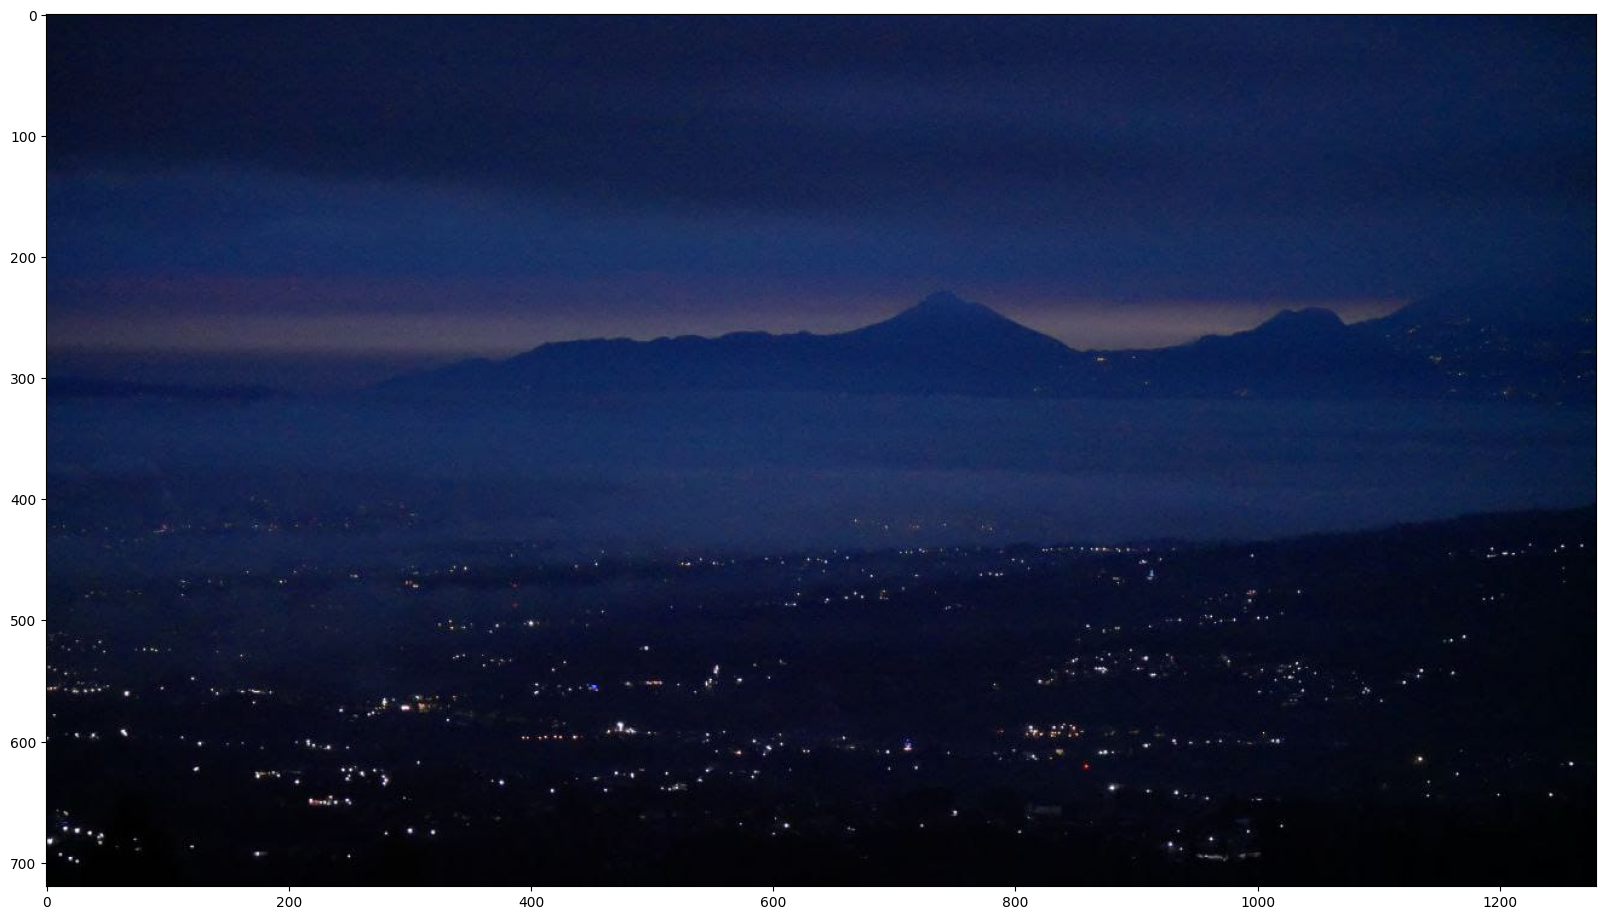

In [ ]:
import matplotlib.pyplot as plt
print("Shape sebelum figsize:", img.shape)

plt.figure(figsize=(20, 20))
plt.imshow(img_cv_rgb)

print("Shape setelah plot figsize (20,20):", img.shape)


Penerapan

NOMOR 1

(np.float64(-0.5), np.float64(353.5), np.float64(471.5), np.float64(-0.5))

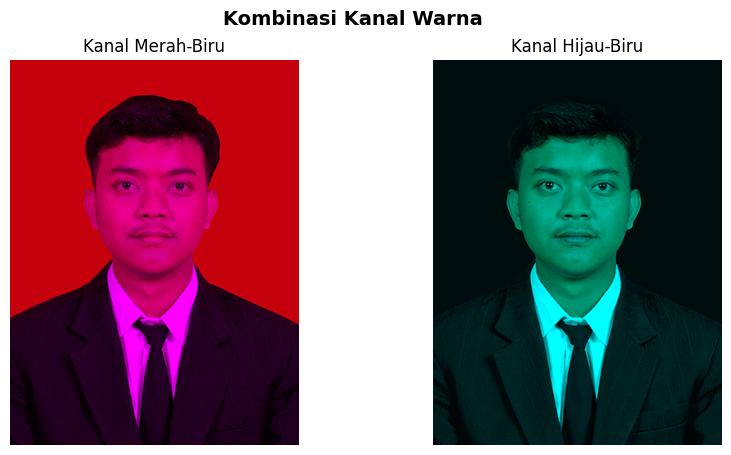

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Baca gambar dan konversi ke RGB
img = cv.imread('/content/drive/MyDrive/PCVK/2337300207-AHlOx.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Kanal Merah-Biru (Hijau dinolkan)
img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0

# Kanal Hijau-Biru (Merah dinolkan)
img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0

# Visualisasi dalam satu figure
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Kombinasi Kanal Warna', fontsize=14, fontweight='bold')

axes[0].imshow(img_rb)
axes[0].set_title('Kanal Merah-Biru')
axes[0].axis('off')

axes[1].imshow(img_gb)
axes[1].set_title('Kanal Hijau-Biru')
axes[1].axis('off')

NOMOR 2

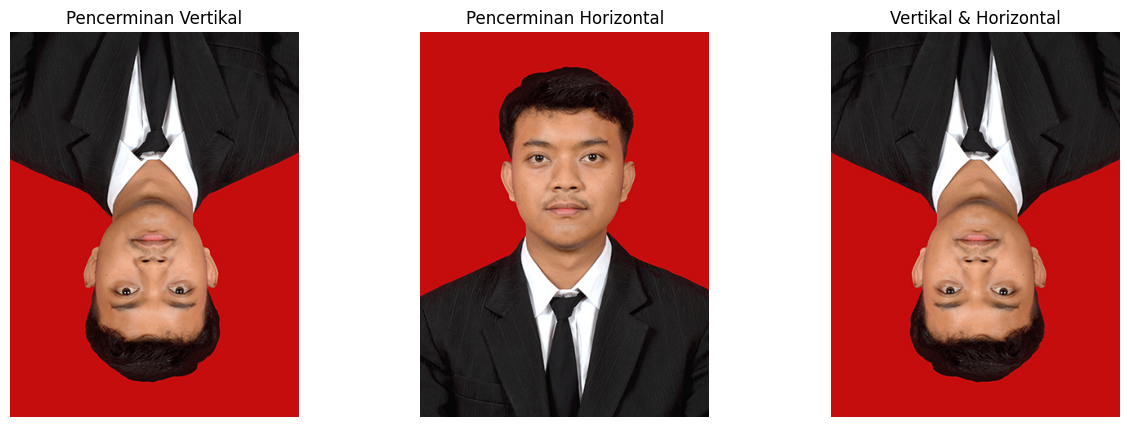

In [ ]:
flip_v = cv.flip(img_rgb, 0)
flip_h = cv.flip(img_rgb, 1)
flip_both = cv.flip(img_rgb, -1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(flip_v)
axes[0].set_title('Pencerminan Vertikal')
axes[0].axis('off')

axes[1].imshow(flip_h)
axes[1].set_title('Pencerminan Horizontal')
axes[1].axis('off')

axes[2].imshow(flip_both)
axes[2].set_title('Vertikal & Horizontal')
axes[2].axis('off')

plt.show()

NOMOR 3

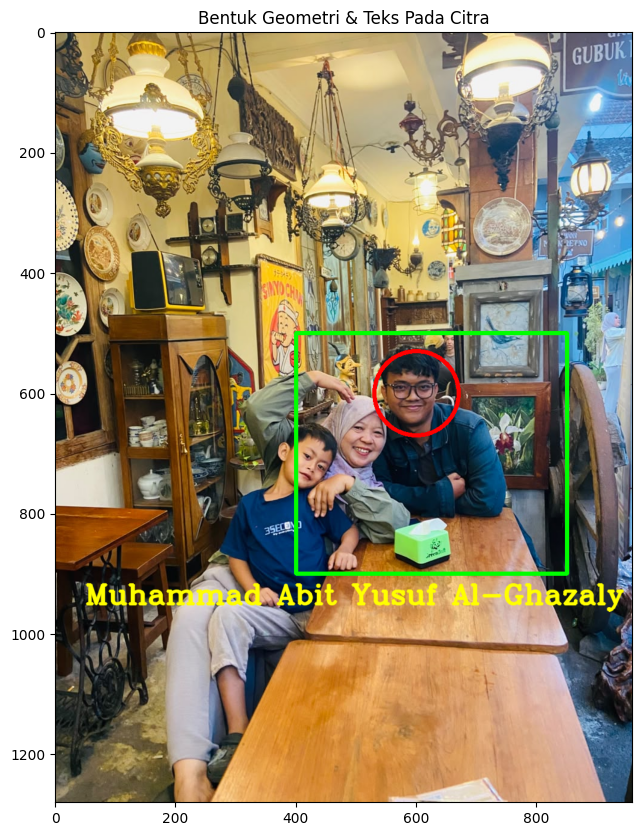

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Pastikan nama file sesuai
img_aktivitas = cv.imread('/content/drive/MyDrive/PCVK/FOTO_FORMAL.jpeg')
img_act_rgb = cv.cvtColor(img_aktivitas, cv.COLOR_BGR2RGB)

# Menggambar Rectangle (Kotak Hijau) di area badan
# Digeser ke kanan (sumbu x dari 550 sampai 850) dan ke bawah (sumbu y 600 ke 900)
cv.rectangle(img_act_rgb, pt1=(400, 500), pt2=(850, 900), color=(0, 255, 0), thickness=5)

# Menggambar Circle (Lingkaran Merah) di area wajah
# Digeser ke atas dan ke kanan (pusat x=670, y=630), radius diperkecil agar pas di wajah
cv.circle(img_act_rgb, center=(600, 600), radius=70, color=(255, 0, 0), thickness=5)

# Menambahkan Teks Nama (Kuning) di bagian bawah
# Titik awal (x) digeser ke 50 dan fontScale diturunkan menjadi 1.5 agar nama panjang tidak terpotong
font = cv.FONT_HERSHEY_COMPLEX
cv.putText(img_act_rgb, text='Muhammad Abit Yusuf Al-Ghazaly', org=(50, 950),
           fontFace=font, fontScale=1.5, color=(255, 255, 0), thickness=3, lineType=cv.LINE_AA)

# Visualisasi Hasil
plt.figure(figsize=(10, 10))
plt.imshow(img_act_rgb)
plt.title('Bentuk Geometri & Teks Pada Citra')
plt.show()